# Evaluation plots

This notebook visualizes how coding schemes and inference parameters affect compression performance. It produces a coding-scheme comparison and three grid-search heatmaps.

Set `USE_DUMMY_DATA = True` to explore the figures with synthetic example values. Set it to `False` to load the checked-in evaluation results. Synthetic figures are written below `artifacts/figures/dummy/`; real figures are written below `artifacts/figures/`.

## Setup and configuration

Import the plotting libraries, locate the repository root, choose between synthetic and real data, and define the input and output paths. Change `GPU` when plotting a different grid-search result file.

In [1]:
import json
import math
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import pandas as pd
import seaborn as sns


def find_repo_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not find the repository root")


REPO_ROOT = find_repo_root()
USE_DUMMY_DATA = True  # Set to False to load the result files below.
CODING_RESULTS = REPO_ROOT / "artifacts/runs/current/compression_results.json"
GPU = "H200"
GRID_RESULTS = REPO_ROOT / f"artifacts/runs/compression_results_ADMS_{GPU}.json"

FIGURE_ROOT = REPO_ROOT / "artifacts/figures"
if USE_DUMMY_DATA:
    FIGURE_ROOT /= "dummy"
CODING_OUTPUT_DIR = FIGURE_ROOT / "coding_schemes"
GRID_OUTPUT_DIR = FIGURE_ROOT / "grid_search"

## Coding-scheme comparison

Compare arithmetic coding, rank with Huffman coding, and rank with bitpacking across batch sizes. The left panel shows the compression ratio, where higher is better; the right panel shows compressed size relative to the input, where lower is better.

### Load and prepare the data

Define the visual style for each scheme and extract the matching `text8` measurements from the result file. The loader validates that all expected scheme and batch-size combinations are present.

In [2]:
SCHEMES = {
    "AC": {"label": "Arithmetic coding", "color": "#1f77b4", "marker": "o"},
    "huffman": {"label": "Rank + Huffman", "color": "#d97706", "marker": "s"},
    "bitpacked": {"label": "Rank + bitpacking", "color": "#2fb344", "marker": "D"},
}


def load_coding_rows(results_path):
    with results_path.open(encoding="utf-8") as handle:
        results = json.load(handle)
    rows = []
    for entry in results.values():
        compression = entry.get("compression", {})
        args = compression.get("args", {})
        encoding = args.get("encoding")
        if (
            args.get("input_path") == "./data/text8"
            and args.get("model_name") == "Qwen/Qwen2.5-0.5B"
            and args.get("first_n_tokens") == 100_000
            and args.get("lora_path") is None
            and args.get("reduce_tokens") is True
            and encoding in SCHEMES
        ):
            rows.append({
                "batch_size": args["batch_size"], "encoding": encoding,
                "original_size": compression["original_size_bytes"],
                "final_size": compression["final_size_bytes"],
                "factor": compression["compression_factor"],
            })
    expected = len(SCHEMES) * 5
    if len(rows) != expected:
        raise ValueError(f"Expected {expected} matching measurements, found {len(rows)}")
    return rows


def add_value_labels(ax, xs, ys, fmt):
    for x, y in zip(xs, ys):
        ax.annotate(fmt(y), (x, y), xytext=(0, 8), textcoords="offset points",
                    ha="center", va="bottom", fontsize=9, color="#303030")

### Generate the comparison figure

Build the two-panel line chart, annotate every measurement, and save both PNG and PDF versions. When dummy mode is enabled, representative synthetic compression factors are created instead of reading the result file.

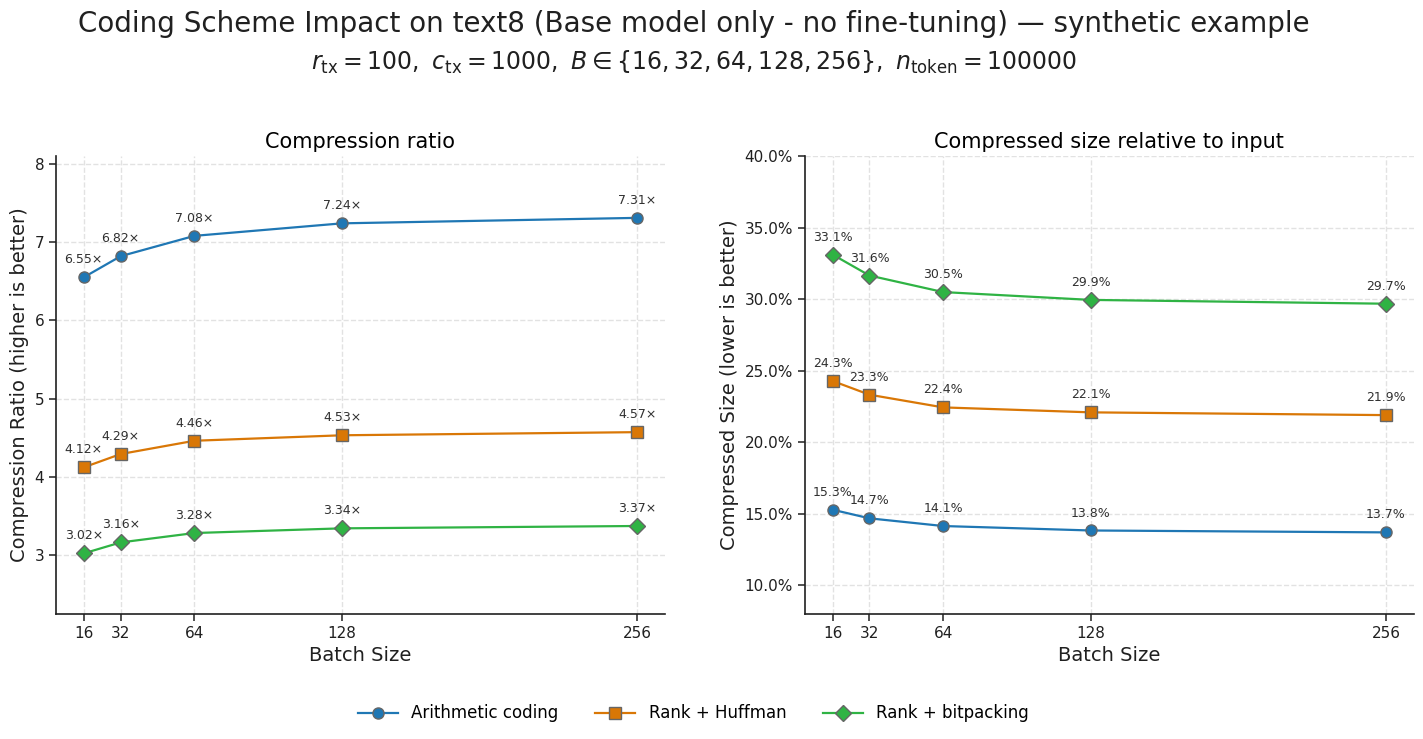

In [3]:
def plot_coding_comparison(rows, output_dir):
    plt.rcParams.update({
        "font.family": "DejaVu Sans", "font.size": 12, "axes.titlesize": 15,
        "axes.labelsize": 14, "xtick.labelsize": 11, "ytick.labelsize": 11,
        "axes.labelcolor": "#202020", "axes.edgecolor": "#202020",
        "xtick.color": "#202020", "ytick.color": "#202020",
    })
    figure, axes = plt.subplots(1, 2, figsize=(15, 7.5), constrained_layout=False)
    figure.patch.set_facecolor("white")
    for ax in axes:
        ax.set_facecolor("white")
        ax.grid(True, color="#D7D7D7", linewidth=1.0, linestyle="--", alpha=0.72)
        ax.set_axisbelow(True)
        ax.spines[["top", "right"]].set_visible(False)
        ax.spines[["left", "bottom"]].set_linewidth(1.2)
        ax.tick_params(axis="both", which="major", length=5, width=1.1)

    for encoding, style in SCHEMES.items():
        scheme_rows = sorted((row for row in rows if row["encoding"] == encoding),
                             key=lambda row: row["batch_size"])
        batches = [row["batch_size"] for row in scheme_rows]
        factors = [row["factor"] for row in scheme_rows]
        size_ratios = [row["final_size"] / row["original_size"] for row in scheme_rows]
        options = {
            "color": style["color"], "marker": style["marker"], "markersize": 8,
            "markeredgecolor": "#666666", "markeredgewidth": 1.0,
            "linewidth": 1.6, "label": style["label"],
        }
        axes[0].plot(batches, factors, **options)
        axes[1].plot(batches, size_ratios, **options)
        add_value_labels(axes[0], batches, factors, lambda value: f"{value:.2f}×")
        add_value_labels(axes[1], batches, size_ratios, lambda value: f"{value:.1%}")

    batch_sizes = sorted({row["batch_size"] for row in rows})
    axes[0].set(title="Compression ratio", xlabel="Batch Size",
                ylabel="Compression Ratio (higher is better)", xticks=batch_sizes)
    axes[0].set_ylim(2.25, 8.1)
    axes[1].set(title="Compressed size relative to input", xlabel="Batch Size",
                ylabel="Compressed Size (lower is better)", xticks=batch_sizes)
    axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
    axes[1].set_ylim(0.08, 0.40)
    handles, labels = axes[0].get_legend_handles_labels()
    figure.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.015),
                  ncol=3, frameon=False, fontsize=12, handlelength=2.4, columnspacing=2.2)
    coding_title = "Coding Scheme Impact on text8 (Base model only - no fine-tuning)"
    if USE_DUMMY_DATA:
        coding_title += " — synthetic example"
    figure.suptitle(coding_title,
                    x=0.5, y=0.985, ha="center", fontsize=20, color="#202020")
    figure.text(0.5, 0.905,
                r"$r_{\mathrm{tx}}=100,\ c_{\mathrm{tx}}=1000,\ "
                r"B\in\{16,32,64,128,256\},\ n_{\mathrm{token}}=100000$",
                ha="center", fontsize=17, color="#202020")
    figure.subplots_adjust(left=0.075, right=0.98, top=0.79, bottom=0.18, wspace=0.23)
    output_dir.mkdir(parents=True, exist_ok=True)
    figure.savefig(output_dir / "coding_scheme_comparison.png", dpi=240,
                   bbox_inches="tight", facecolor="white")
    figure.savefig(output_dir / "coding_scheme_comparison.pdf",
                   bbox_inches="tight", facecolor="white")
    return figure


if USE_DUMMY_DATA:
    dummy_factors = {
        "AC": [6.55, 6.82, 7.08, 7.24, 7.31],
        "huffman": [4.12, 4.29, 4.46, 4.53, 4.57],
        "bitpacked": [3.02, 3.16, 3.28, 3.34, 3.37],
    }
    coding_rows = [
        {
            "batch_size": batch_size, "encoding": encoding,
            "original_size": 100_000, "final_size": 100_000 / factor,
            "factor": factor,
        }
        for encoding, factors in dummy_factors.items()
        for batch_size, factor in zip([16, 32, 64, 128, 256], factors)
    ]
else:
    coding_rows = load_coding_rows(CODING_RESULTS)
plot_coding_comparison(coding_rows, CODING_OUTPUT_DIR);

## Batch-size/context-length grid search

Show how batch size and context-window length jointly affect throughput, compression factor, and pure compression factor. Each heatmap cell is the mean value for one parameter combination.

### Define the heatmap layout

Specify the batch sizes and context lengths to include, configure Matplotlib, and define a reusable function that reshapes measurements into a table and renders it with Seaborn.

In [4]:
BATCH_SIZES = [4, 16, 64, 128, 256, 512, 1024, 2048]
CONTEXT_LENGTHS = [32, 64, 128, 256, 512, 1024, 2048]
matplotlib.rcParams.update({
    "font.size": 11, "font.family": "serif", "axes.titlesize": "medium",
    "figure.titlesize": "medium", "text.usetex": False,
    "mathtext.fontset": "dejavuserif",
})


def plot_grid_heatmap(results, metric, title, label, filename, output_dir):
    rows = []
    for result in results.values():
        args = result["compression"]["args"]
        if args["batch_size"] not in BATCH_SIZES or args["context_length"] not in CONTEXT_LENGTHS:
            continue
        rows.append({
            "context_len": int(args["context_length"]),
            "batch_size": int(args["batch_size"]),
            "value": metric(result),
        })
    frame = (pd.DataFrame(rows).groupby(["context_len", "batch_size"])["value"].mean().unstack())
    figure, ax = plt.subplots(figsize=(4.9, 3.5))
    sns.heatmap(frame, annot=True, fmt=".2f", linewidths=0.5,
                cbar_kws={"label": label}, ax=ax)
    ax.set(xlabel="Batch Size", ylabel="Context Window Size", title=title)
    figure.tight_layout()
    output_dir.mkdir(parents=True, exist_ok=True)
    figure.savefig(output_dir / f"{filename}.png", dpi=300,
                   bbox_inches="tight", pad_inches=0.01)
    return figure

### Generate the grid-search figures

Create illustrative values in dummy mode or load the selected GPU result file in real-data mode. The final loop renders one heatmap for throughput and two for compression quality.

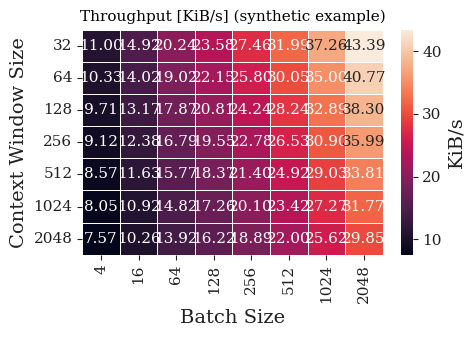

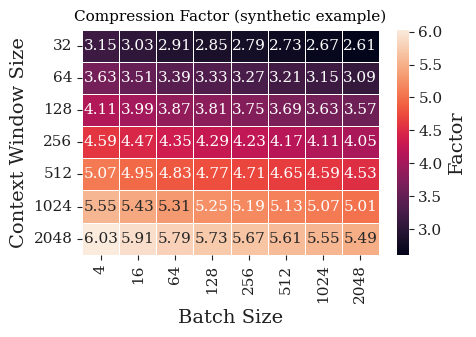

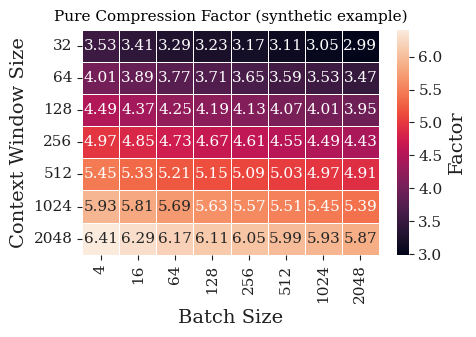

In [5]:
if USE_DUMMY_DATA:
    grid_results = {}
    for context_length in CONTEXT_LENGTHS:
        for batch_size in BATCH_SIZES:
            throughput = 11.0 * (batch_size / 4) ** 0.22 * (32 / context_length) ** 0.09
            compression_factor = (
                3.15 + 0.48 * math.log2(context_length / 32)
                - 0.06 * math.log2(batch_size / 4)
            )
            grid_results[f"{context_length}-{batch_size}"] = {
                "compression": {
                    "args": {"context_length": context_length, "batch_size": batch_size},
                    "inference_throughput_kibibytes_per_sec": throughput,
                    "compression_factor": compression_factor,
                    "pure_compression_factor": compression_factor + 0.38,
                }
            }
else:
    with GRID_RESULTS.open(encoding="utf-8") as handle:
        grid_results = json.load(handle)

data_label = "synthetic example" if USE_DUMMY_DATA else GPU
grid_plots = [
    (lambda stats: float(stats["compression"]["inference_throughput_kibibytes_per_sec"]),
     f"Throughput [KiB/s] ({data_label})", "KiB/s", f"inference_throughput_heatmap_{GPU}"),
    (lambda stats: float(stats["compression"]["compression_factor"]),
     f"Compression Factor ({data_label})", "Factor", f"compression_factor_heatmap_{GPU}"),
    (lambda stats: float(stats["compression"]["pure_compression_factor"]),
     f"Pure Compression Factor ({data_label})", "Factor", f"pure_compression_factor_heatmap_{GPU}"),
]

for metric, title, label, filename in grid_plots:
    plot_grid_heatmap(grid_results, metric, title, label, filename, GRID_OUTPUT_DIR)

## Reading the figures

For the coding-scheme chart, compare both the absolute performance and how each line changes as batch size grows. For the heatmaps, scan rows and columns to identify parameter regions that balance throughput with compression quality.

> The synthetic values are designed only to demonstrate the plots and should not be interpreted as experimental results.